In [17]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.special import genlaguerre, gammaln
import itertools
import scienceplots
plt.style.use(['science', 'notebook'])


def ssh_energies(band, omega_q, gc1, gc2, k):
    delta = np.sqrt(gc1**2 + gc2**2 + 2 * gc1 * gc2 * np.cos(k))
    if band == 0:
        energy = omega_q * np.sqrt(1 + 2 * delta / omega_q)
    elif band == 1:
        energy = omega_q * np.sqrt(1 - 2 * delta / omega_q)
        
    return energy

def first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, fock_alpha, fock_beta):
    fock_alpha = np.asarray(fock_alpha, dtype=float)
    fock_beta  = np.asarray(fock_beta,  dtype=float)
    assert len(fock_alpha) == n and len(fock_beta) == n, \
        "fock_alpha and fock_beta must each have length n (number of unit cells)"

    # ------------------------------------------------------------------ #
    # Physical parameters
    # ------------------------------------------------------------------ #
    omega_q = np.sqrt(8.0 * E_c * E_j) - E_c
    g_scale = np.sqrt(E_j * E_c**3) / np.sqrt(2.0)
    nu      = g_scale / E_g_nu          # intracell hopping
    w       = g_scale / E_g_w           # intercell hopping
    U       = E_c / 2.0                 # Kerr coefficient
    N_sites = 2 * n

    # ------------------------------------------------------------------ #
    # SSH momenta and coupling  |Δk| = |nu + w*e^{ik}|
    # ------------------------------------------------------------------ #
    k  = np.linspace(-np.pi, np.pi, n, endpoint=False)
    Dk = np.sqrt(nu**2 + w**2 + 2.0 * nu * w * np.cos(k))   # |Δk|, shape (n,)

    # ------------------------------------------------------------------ #
    # BdG eigenvalues
    # ------------------------------------------------------------------ #
    E_plus  = np.sqrt((omega_q ) * (omega_q + 2*Dk))
    E_minus = np.sqrt((omega_q) * (omega_q - 2*Dk))

    if np.any(omega_q - 2*Dk < 0):
        import warnings
        warnings.warn(
            "Antibonding branch has imaginary frequencies (omega_q + 2U < 2|Δk|). "
            "The perturbative expansion may be unreliable.",
            RuntimeWarning
        )

    # ------------------------------------------------------------------ #
    # Bogoliubov coherence factors
    # ------------------------------------------------------------------ #
    cosh2_plus  = (omega_q + Dk) / E_plus       # cosh(2θ+)
    cosh2_minus = (omega_q - Dk) / E_minus      # cosh(2θ-)

    sinh2_plus  = ( Dk) / E_plus           # sinh(2θ+)
    sinh2_minus = ( - Dk) / E_minus          # sinh(2θ-)

    sinh2th_plus  = (omega_q + Dk - E_plus)  / (2.0 * E_plus)   # sinh²θ+
    sinh2th_minus = (omega_q - Dk - E_minus) / (2.0 * E_minus)  # sinh²θ-

    # ------------------------------------------------------------------ #
    # Vacuum sums  S = Σ_k sinh²θ  (c-numbers)
    # ------------------------------------------------------------------ #
    S_alpha = np.sum(sinh2th_plus)
    S_beta  = np.sum(sinh2th_minus)

    # ------------------------------------------------------------------ #
    # B_total = P_alpha + P_beta + S_alpha + S_beta
    # (the -N_sites/2 is absorbed: sum cosh(2θ)/2 - 1/2 = sinh²θ = S)
    # ------------------------------------------------------------------ #
    P_alpha = np.sum(cosh2_plus  * fock_alpha)
    P_beta  = np.sum(cosh2_minus * fock_beta)
    B_total = P_alpha + P_beta + S_alpha + S_beta

    # ------------------------------------------------------------------ #
    # C_total = Σ_k [ sinh(2θ+)(n_α+1/2) + sinh(2θ-)(n_β+1/2) ]
    # ------------------------------------------------------------------ #
    C_total = (np.sum(sinh2_plus  * (fock_alpha + 0.5))
             + np.sum(sinh2_minus * (fock_beta  + 0.5)))

    # ------------------------------------------------------------------ #
    # Constant D = (3/8) Σ_k [ sinh²(2θ+) + sinh²(2θ-) ]
    # ------------------------------------------------------------------ #
    D = (3.0 / 8.0) * (np.sum(sinh2_plus**2) + np.sum(sinh2_minus**2))

    # ------------------------------------------------------------------ #
    # H_eff = (2U / N_sites) * [ -B^2 + (1/2)C^2 + B - D ]
    # ------------------------------------------------------------------ #
    return (2.0 * U / N_sites) * (
        - B_total**2
        + 0.5 * C_total**2
        + B_total
        - D
    )


def first_order_interaction(E_j, E_c, E_g, n, fock_state):
    """
    Original simple-chain formula (reference, unchanged).

    Parameters
    ----------
    E_j, E_c, E_g : float
        Physical parameters.
    n : int
        Number of sites.
    fock_state : array-like, length n
        Bogoliubov occupation numbers.

    Returns
    -------
    float
        First-order Kerr energy.
    """
    omega_q   = np.sqrt(8 * E_c * E_j) - E_c
    g         = (E_j * E_c**3)**0.5 / (np.sqrt(2) * E_g)
    k_values  = np.linspace(-np.pi, np.pi, n, endpoint=False)
    lamb      = E_c / 12.0
    U         = 6 * lamb
    epsilon_k = lambda k: omega_q + 2 * g * np.cos(k)
    delta_k   = lambda k: 2 * g * np.cos(k)

    A, B, C = 0.0, -n / 2.0, 0.0
    for k, occupation in zip(k_values, fock_state):
        Ek = np.sqrt(epsilon_k(k)**2 - delta_k(k)**2)
        A += delta_k(k)   * (occupation + 0.5) / Ek
        B += epsilon_k(k) * (occupation + 0.5) / Ek
        C += (3.0 / 8.0)  * delta_k(k)**2 / (epsilon_k(k)**2 - delta_k(k)**2)

    return 2 * U * (0.5 * A**2 - B**2 + B - C) / n


# --------------------------------------------------------------------------- #
# Comprobamos si en el limite de hoppings iguales las funciones dan lo mismo y si realmente difieren cuando no
# --------------------------------------------------------------------------- #
if __name__ == "__main__":

    E_j, E_c, E_g = 20.0, 0.3, 5.0
    n_cells = 20
    rng = np.random.default_rng(42)

    # BZ unfolding map: alpha[i] -> chain q=k[i]/2, beta[i] -> chain q=π-k[i]/2
    def ssh_to_chain_fock(fa, fb, n):
        kc = np.linspace(-np.pi, np.pi, 2*n, endpoint=False)
        ks = np.linspace(-np.pi, np.pi, n,   endpoint=False)
        fc = np.zeros(2*n)
        for i in range(n):
            ia = np.argmin(np.abs(kc - ks[i] / 2.0))
            qb = ((np.pi - ks[i] / 2.0 + np.pi) % (2*np.pi)) - np.pi
            ib = np.argmin(np.abs(kc - qb))
            fc[ia] += fa[i]
            fc[ib] += fb[i]
        return fc

    # ------------------------------------------------------------------ #
    print("Test 1: simple-chain limit  (nu = w = g,  E_g_nu = E_g_w)")
    print(f"{'State':<24} {'SSH H_eff':>14} {'Chain H_eff':>14} {'Match':>6}")
    print("-" * 62)

    cases = [
        ("vacuum",        np.zeros(n_cells), np.zeros(n_cells)),
        ("1 alpha k[0]",  np.eye(n_cells)[0], np.zeros(n_cells)),
        ("1 beta  k[5]",  np.zeros(n_cells),  np.eye(n_cells)[5]),
        ("2 alpha k[3]",  2*np.eye(n_cells)[3], np.zeros(n_cells)),
        ("alpha+beta",    np.eye(n_cells)[2],  np.eye(n_cells)[7]),
        ("random",        rng.integers(0,3,n_cells).astype(float),
                          rng.integers(0,3,n_cells).astype(float)),
    ]

    all_pass = True
    for label, fa, fb in cases:
        E_ssh   = first_order_interaction_ssh(E_j, E_c, E_g, E_g, n_cells, fa, fb)
        fc      = ssh_to_chain_fock(fa, fb, n_cells)
        E_chain = first_order_interaction(E_j, E_c, E_g, 2*n_cells, fc)
        ok      = np.isclose(E_ssh, E_chain, rtol=1e-6)
        all_pass &= ok
        print(f"{label:<24} {E_ssh:>14.6f} {E_chain:>14.6f} {'✓' if ok else '✗':>6}")

    print(f"All chain-limit tests passed: {all_pass}\n")

    # ------------------------------------------------------------------ #
    print("Test 2: genuine SSH (nu != w)  —  alpha vs beta asymmetry")
    print(f"{'State':<30} {'H_eff':>12}")
    print("-" * 46)

    E_g_nu, E_g_w = 4.0, 7.0    # nu != w => true SSH dimerization
    fa1 = np.zeros(n_cells); fa1[n_cells//2] = 1
    fb1 = np.zeros(n_cells); fb1[n_cells//2] = 1
    fv  = np.zeros(n_cells)

    Ev  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fv)
    Ea  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fv)
    Eb  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fb1)
    Eab = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fb1)

    for label, val in [
        ("vacuum",               Ev),
        ("1 alpha qp (k=k[n/2])", Ea),
        ("1 beta  qp (k=k[n/2])", Eb),
        ("1 alpha + 1 beta",      Eab),
    ]:
        print(f"{label:<30} {val:>12.6f}")

    print()
    print(f"alpha Kerr shift: {Ea-Ev:+.6f}")
    print(f"beta  Kerr shift: {Eb-Ev:+.6f}")
    print("(These differ because nu != w breaks alpha <-> beta symmetry)")

Test 1: simple-chain limit  (nu = w = g,  E_g_nu = E_g_w)
State                         SSH H_eff    Chain H_eff  Match
--------------------------------------------------------------
vacuum                        -0.000018      -0.000018      ✓
1 alpha k[0]                  -0.000092      -0.000092      ✓
1 beta  k[5]                  -0.000091      -0.000091      ✓
2 alpha k[3]                  -0.015170      -0.015170      ✓
alpha+beta                    -0.015174      -0.015174      ✓
random                       -14.860685     -14.860685      ✓
All chain-limit tests passed: True

Test 2: genuine SSH (nu != w)  —  alpha vs beta asymmetry
State                                 H_eff
----------------------------------------------
vacuum                            -0.000019
1 alpha qp (k=k[n/2])             -0.000098
1 beta  qp (k=k[n/2])             -0.000093
1 alpha + 1 beta                  -0.015194

alpha Kerr shift: -0.000079
beta  Kerr shift: -0.000074
(These differ because nu !=

In [18]:
E_j       = 50.0
E_c       = 1.0
prefactor = np.sqrt(E_j * E_c**3) / np.sqrt(2.0)
omega_q   = np.sqrt(8 * E_c * E_j) - E_c          # correct formula
U         = E_c / 2.0                              # correct: E_c/2, not 1.0
n         = 100
k_values  = np.linspace(-np.pi, np.pi, n)

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Computer Modern Roman'],
    'text.usetex':       True,
    'font.size':         9,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'axes.linewidth':    0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.5,  # fix: minor ticks same weight as major
    'ytick.minor.width': 0.5,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.minor.size':  1.5,
    'ytick.minor.size':  1.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'figure.dpi':        300,
})

colors  = ['#03AED2', '#D12052', '#F8DE22', '#F45B26']
markers = ['o', 's', '^', 'D']
# ms      = 9
# max_bands1 = 9
# max_bands2 = 12
# fig, ax = plt.subplots(figsize=(3.4, 2.8))

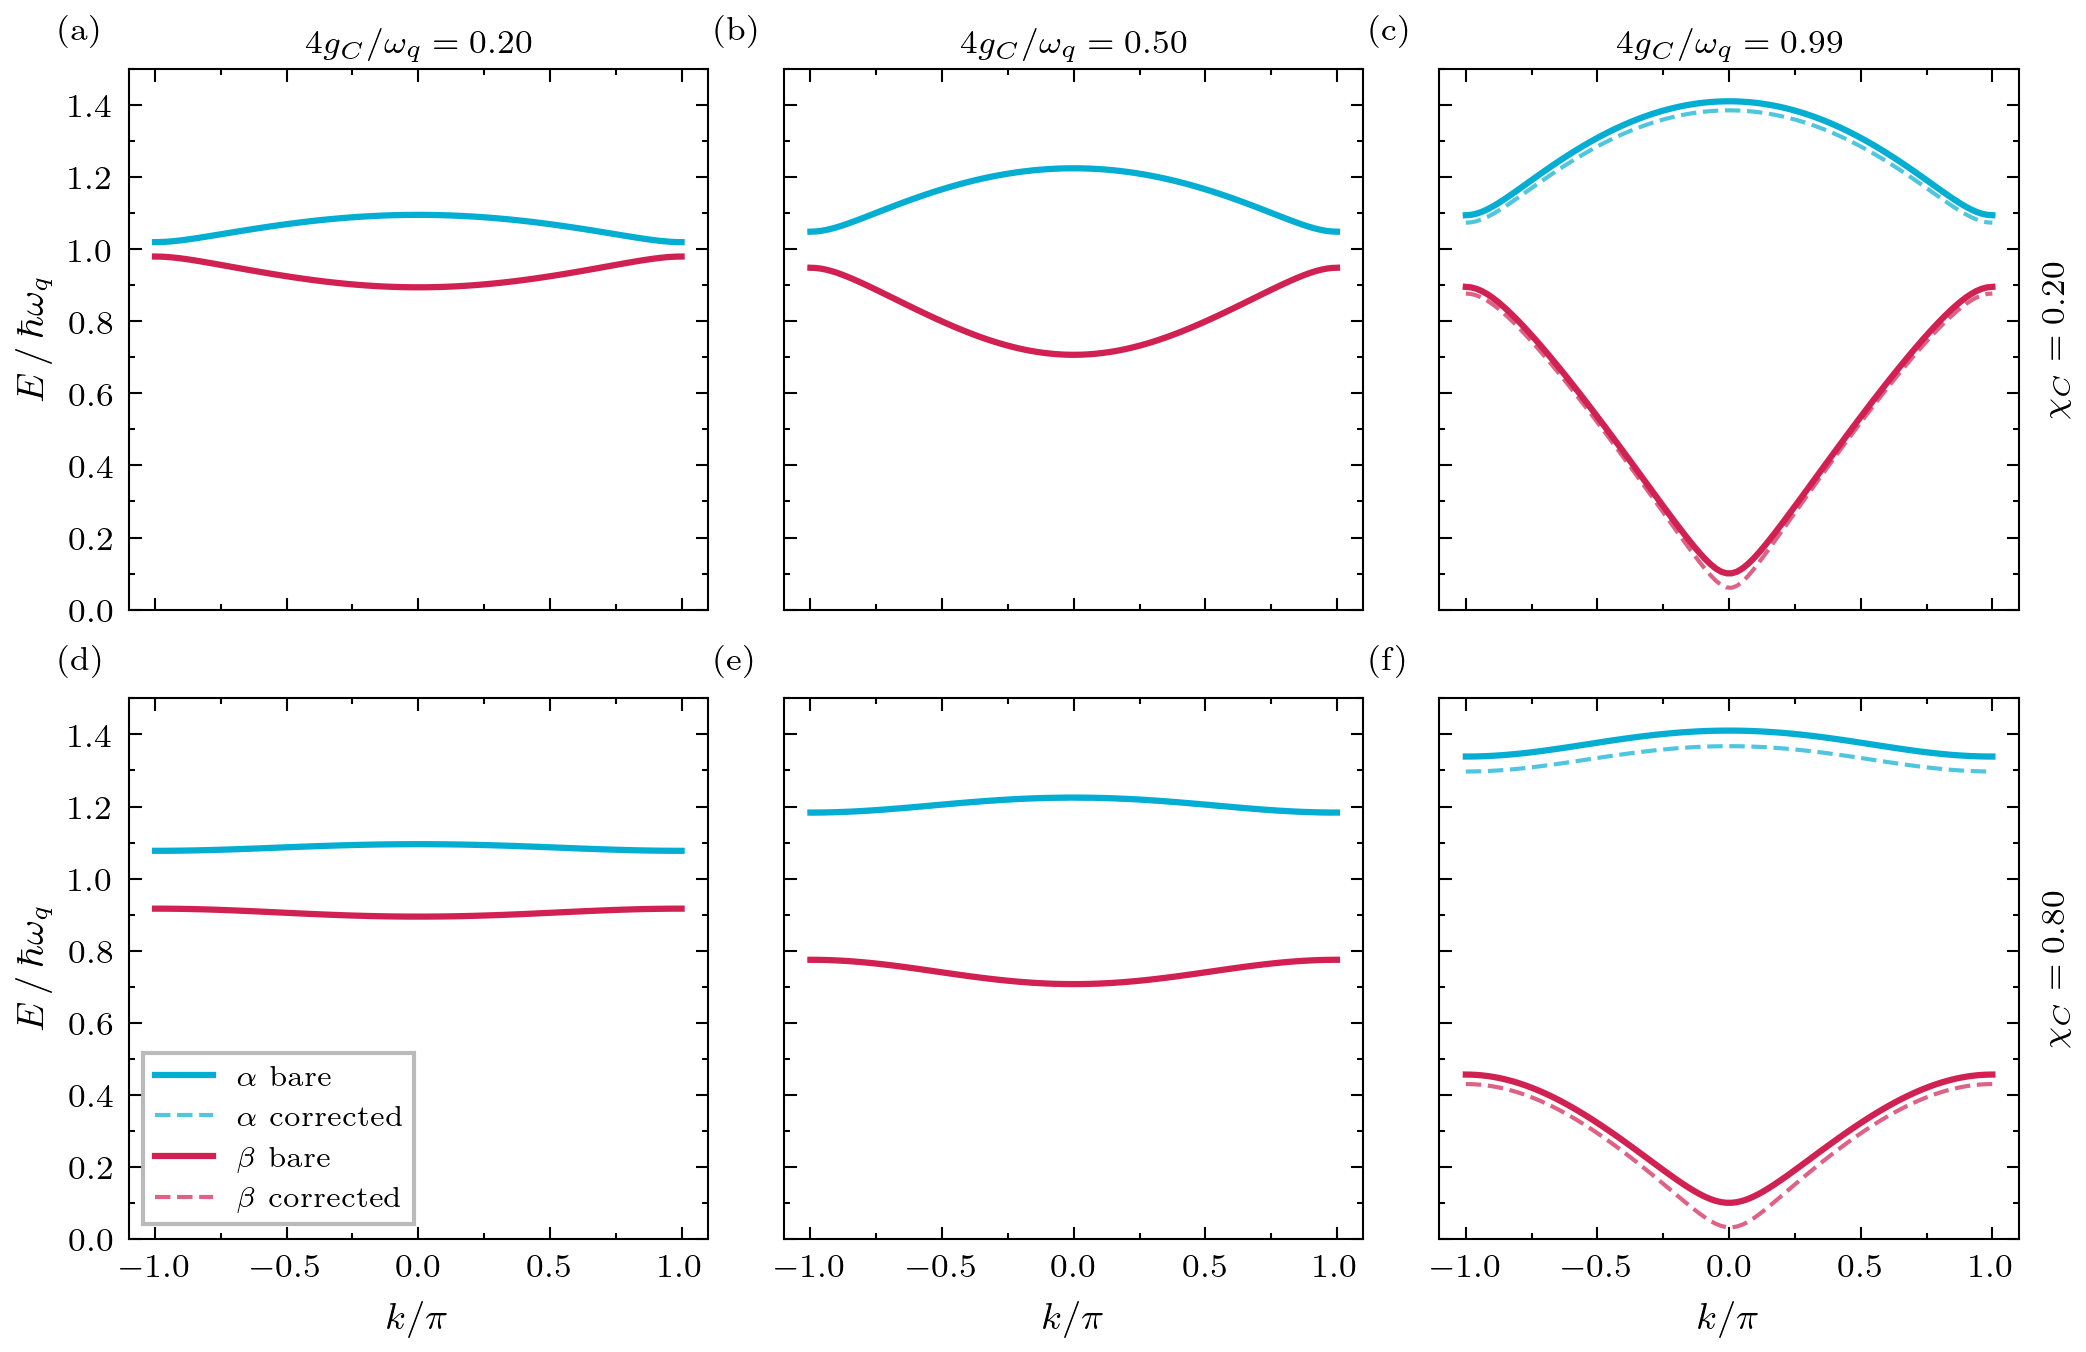

In [32]:
# ------------------------------------------------------------------ #
# Figure parameters
# ------------------------------------------------------------------ #
chi_values  = np.array([0.2, 0.8])
twog_values = omega_q * np.array([0.2, 0.5, 0.99]) / 4.0

params     = list(itertools.product(chi_values, twog_values))
nu_w_pairs = [(twog * (1 + chi), twog * (1 - chi)) for chi, twog in params]

nrows, ncols   = 2, 3
fig_width      = 7.0
fig_height     = 4.5
ylim           = (0.0, 1.5)
panel_fontsize = 8

# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(fig_width, fig_height))

for idx, ((nu, w), ax) in enumerate(zip(nu_w_pairs, axes.flatten())):
    chi, twog = params[idx]
    E_g_nu = prefactor / nu
    E_g_w  = prefactor / w

    # --- corrections ---
    E_vac = first_order_interaction_ssh(
        E_j, E_c, E_g_nu, E_g_w, n,
        np.zeros(n), np.zeros(n)
    )
    beta_correction = np.array([
        first_order_interaction_ssh(
            E_j, E_c, E_g_nu, E_g_w, n,
            np.zeros(n), np.eye(n)[j]
        ) for j in range(n)
    ]) - E_vac
    alpha_correction = np.array([
        first_order_interaction_ssh(
            E_j, E_c, E_g_nu, E_g_w, n,
            np.eye(n)[j], np.zeros(n)
        ) for j in range(n)
    ]) - E_vac

    # --- bare dispersions ---
    E_alpha_bare = ssh_energies(0, omega_q, nu, w, k_values)
    E_beta_bare  = ssh_energies(1, omega_q, nu, w, k_values)

    # --- plot ---
    l1, = ax.plot(k_values / np.pi, E_beta_bare / omega_q,
                  color=colors[1], lw=1.5)
    l2, = ax.plot(k_values / np.pi, (E_beta_bare + beta_correction) / omega_q,
                  color=colors[1], lw=1.0, ls='--', alpha=0.7)
    l3, = ax.plot(k_values / np.pi, E_alpha_bare / omega_q,
                  color=colors[0], lw=1.5)
    l4, = ax.plot(k_values / np.pi, (E_alpha_bare + alpha_correction) / omega_q,
                  color=colors[0], lw=1.0, ls='--', alpha=0.7)

    ax.set_ylim(*ylim)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    # panel label
    ax.text(-0.12, 1.04, f'({chr(97+idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')

    # x-axis label only on bottom row
    if idx >= ncols:
        ax.set_xlabel(r'$k/\pi$')
    else:
        ax.tick_params(labelbottom=False)

    # y-axis label only on left column
    if idx % ncols == 0:
        ax.set_ylabel(r'$E\,/\,\hbar\omega_q$')
    else:
        ax.tick_params(labelleft=False)

# --- column headers: 2g value on top of each column ---
for col, twog in enumerate(twog_values):
    axes[0, col].set_title(
        rf'$4g_C/\omega_q = {4*twog/omega_q:.2f}$',
        fontsize=8, pad=4
    )

# --- row headers: chi value on right side of each row ---
for row, chi in enumerate(chi_values):
    axes[row, -1].annotate(
        rf'$\chi_C = {chi:.2f}$',
        xy=(1.04, 0.5), xycoords='axes fraction',
        fontsize=8, va='center', ha='left',
        rotation=90
    )

# --- legend inside bottom-right panel ---
axes[1, 0].legend(
    [l3, l4, l1, l2],
    [r'$\alpha$ bare', r'$\alpha$ corrected',
     r'$\beta$ bare',  r'$\beta$ corrected'],
    fontsize=7, frameon=True,
    framealpha=0.9, edgecolor='0.7',
    fancybox=False, loc='lower left',
)

fig.tight_layout(pad=0.4, h_pad=0.5, w_pad=0.5)
fig.savefig('../../../figures/export/ssh_chain_spectrum.pdf', bbox_inches='tight', dpi = 600)
plt.show()

In [ ]:

# def first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, fock_alpha, fock_beta):
#     """
#     First-order Kerr effective Hamiltonian for the SSH polariton chain.

#     The SSH chain has two sublattice sites (A, B) per unit cell with TWO
#     distinct hoppings:
#         nu  (intracell:  A -> B within the same cell)
#         w   (intercell:  B -> A between neighbouring cells)

#     This gives two Bogoliubov branches (alpha = bonding, beta = antibonding).
#     The SSH coupling at momentum k is:

#         |Δk| = sqrt(nu^2 + w^2 + 2*nu*w*cos(k))

#     Due to the sublattice parity selection rule (A and B enter the beta branch
#     with opposite signs), the quartic Kerr interaction decomposes as:

#         Σ_σ b†_{pσ}b†_{qσ}b_{rσ}b_{sσ} = 2(αααα) + 2(ααββ) + 2(ββββ)

#     Applying the simple-chain formula sector by sector and collecting:

#         H_eff = (2U / N_sites) * [
#             - B_total^2
#             + (1/2) * C_total^2
#             + B_total
#             - (3/8) * Σ_k [ sinh^2(2θ+_k) + sinh^2(2θ-_k) ]
#         ]

#     where:
#         B_total = P_alpha + P_beta + S_alpha + S_beta
#         C_total = Σ_k [ sinh(2θ+_k)(n̂_α(k)+1/2) + sinh(2θ-_k)(n̂_β(k)+1/2) ]

#         P_alpha = Σ_k cosh(2θ+_k) n̂_α(k)
#         P_beta  = Σ_k cosh(2θ-_k) n̂_β(k)
#         S_alpha = Σ_k sinh²(θ+_k)    (vacuum squeezing, c-number)
#         S_beta  = Σ_k sinh²(θ-_k)    (vacuum squeezing, c-number)

#     The -N_sites/2 of the chain formula is absorbed:
#         sum cosh(2θ)/2 - 1/2 = sinh²θ  =>  S already contains it.

#     Simple-chain limit: set E_g_nu = E_g_w (=> nu = w = g).
#     With BZ unfolding (alpha at k <-> chain at q=k/2, beta at k <-> chain at
#     q=π-k/2) the formula collapses exactly to first_order_interaction().

#     Parameters
#     ----------
#     E_j : float
#         Josephson energy.
#     E_c : float
#         Charging energy (on-site frequency and Kerr).
#     E_g_nu : float
#         Coupling energy for the intracell hopping nu.
#         nu = sqrt(E_j * E_c^3) / (sqrt(2) * E_g_nu)
#     E_g_w : float
#         Coupling energy for the intercell hopping w.
#         w  = sqrt(E_j * E_c^3) / (sqrt(2) * E_g_w)
#         Set E_g_w = E_g_nu to recover the simple-chain limit (nu = w).
#     n : int
#         Number of unit cells. Total sites N_sites = 2n.
#         SSH BZ: k in [-pi, pi), n momenta.
#     fock_alpha : array-like, length n
#         Bogoliubov occupation numbers for the alpha (bonding) branch.
#     fock_beta : array-like, length n
#         Bogoliubov occupation numbers for the beta (antibonding) branch.

#     Returns
#     -------
#     float
#         First-order Kerr energy for the given Fock state.

#     Notes
#     -----
#     Physical parameters:
#         omega_q = sqrt(8 E_c E_j) - E_c
#         nu      = sqrt(E_j E_c^3) / (sqrt(2) E_g_nu)   intracell hopping
#         w       = sqrt(E_j E_c^3) / (sqrt(2) E_g_w)    intercell hopping
#         U       = E_c / 2   (= 6*lambda,  lambda = E_c/12)

#     SSH coupling:
#         |Δk| = sqrt(nu^2 + w^2 + 2*nu*w*cos(k))

#     BdG eigenvalues:
#         E+_k = sqrt((omega_q - 2U)(omega_q + 2U + 2|Δk|))   bonding
#         E-_k = sqrt((omega_q - 2U)(omega_q + 2U - 2|Δk|))   antibonding

#     Bogoliubov angles:
#         cosh(2θ±_k) = (omega_q ± |Δk|) / E±_k
#         sinh(2θ±_k) = (2U     ± |Δk|) / E±_k
#         sinh²(θ±_k) = (omega_q ± |Δk| - E±_k) / (2 E±_k)
#     """
#     fock_alpha = np.asarray(fock_alpha, dtype=float)
#     fock_beta  = np.asarray(fock_beta,  dtype=float)
#     assert len(fock_alpha) == n and len(fock_beta) == n, \
#         "fock_alpha and fock_beta must each have length n (number of unit cells)"

#     # ------------------------------------------------------------------ #
#     # Physical parameters
#     # ------------------------------------------------------------------ #
#     omega_q = np.sqrt(8.0 * E_c * E_j) - E_c
#     g_scale = np.sqrt(E_j * E_c**3) / np.sqrt(2.0)
#     nu      = g_scale / E_g_nu          # intracell hopping
#     w       = g_scale / E_g_w           # intercell hopping
#     U       = E_c / 2.0                 # Kerr coefficient
#     N_sites = 2 * n

#     # ------------------------------------------------------------------ #
#     # SSH momenta and coupling  |Δk| = |nu + w*e^{ik}|
#     # ------------------------------------------------------------------ #
#     k  = np.linspace(-np.pi, np.pi, n, endpoint=False)
#     Dk = np.sqrt(nu**2 + w**2 + 2.0 * nu * w * np.cos(k))   # |Δk|, shape (n,)

#     # ------------------------------------------------------------------ #
#     # BdG eigenvalues
#     # ------------------------------------------------------------------ #
#     E_plus  = np.sqrt((omega_q ) * (omega_q  + 2*Dk))
#     E_minus = np.sqrt((omega_q ) * (omega_q  - 2*Dk))

#     if np.any(omega_q - 2*Dk < 0):
#         import warnings
#         warnings.warn(
#             "Antibonding branch has imaginary frequencies (omega_q + 2U < 2|Δk|). "
#             "The perturbative expansion may be unreliable.",
#             RuntimeWarning
#         )

#     # ------------------------------------------------------------------ #
#     # Bogoliubov coherence factors
#     # ------------------------------------------------------------------ #
#     cosh2_plus  = (omega_q + Dk) / E_plus       # cosh(2θ+)
#     cosh2_minus = (omega_q - Dk) / E_minus      # cosh(2θ-)

#     sinh2_plus  = (Dk) / E_plus           # sinh(2θ+)
#     sinh2_minus = (- Dk) / E_minus          # sinh(2θ-)

#     sinh2th_plus  = (omega_q + Dk - E_plus)  / (2.0 * E_plus)   # sinh²θ+
#     sinh2th_minus = (omega_q - Dk - E_minus) / (2.0 * E_minus)  # sinh²θ-

#     # ------------------------------------------------------------------ #
#     # Vacuum sums  S = Σ_k sinh²θ  (c-numbers)
#     # ------------------------------------------------------------------ #
#     S_alpha = np.sum(sinh2th_plus)
#     S_beta  = np.sum(sinh2th_minus)

#     # ------------------------------------------------------------------ #
#     # B_total = P_alpha + P_beta + S_alpha + S_beta
#     # (the -N_sites/2 is absorbed: sum cosh(2θ)/2 - 1/2 = sinh²θ = S)
#     # ------------------------------------------------------------------ #
#     P_alpha = np.sum(cosh2_plus  * fock_alpha)
#     P_beta  = np.sum(cosh2_minus * fock_beta)
#     B_total = P_alpha + P_beta + S_alpha + S_beta

#     # ------------------------------------------------------------------ #
#     # C_total = Σ_k [ sinh(2θ+)(n_α+1/2) + sinh(2θ-)(n_β+1/2) ]
#     # ------------------------------------------------------------------ #
#     C_total = (np.sum(sinh2_plus  * (fock_alpha + 0.5))
#              + np.sum(sinh2_minus * (fock_beta  + 0.5)))

#     # ------------------------------------------------------------------ #
#     # Constant D = (3/8) Σ_k [ sinh²(2θ+) + sinh²(2θ-) ]
#     # ------------------------------------------------------------------ #
#     D = (3.0 / 8.0) * (np.sum(sinh2_plus**2) + np.sum(sinh2_minus**2))

#     # ------------------------------------------------------------------ #
#     # H_eff = (2U / N_sites) * [ -B^2 + (1/2)C^2 + B - D ]
#     # ------------------------------------------------------------------ #
#     return (2.0 * U / N_sites) * (
#         - B_total**2
#         + 0.5 * C_total**2
#         + B_total
#         - D
#     )


# def first_order_interaction(E_j, E_c, E_g, n, fock_state):
#     """
#     Original simple-chain formula (reference, unchanged).

#     Parameters
#     ----------
#     E_j, E_c, E_g : float
#         Physical parameters.
#     n : int
#         Number of sites.
#     fock_state : array-like, length n
#         Bogoliubov occupation numbers.

#     Returns
#     -------
#     float
#         First-order Kerr energy.
#     """
#     omega_q   = np.sqrt(8 * E_c * E_j) - E_c
#     g         = (E_j * E_c**3)**0.5 / (np.sqrt(2) * E_g)
#     k_values  = np.linspace(-np.pi, np.pi, n, endpoint=False)
#     lamb      = E_c / 12.0
#     U         = 6 * lamb
#     epsilon_k = lambda k: omega_q + 2 * g * np.cos(k)
#     delta_k   = lambda k: 2 * g * np.cos(k) + 12 * lamb

#     A, B, C = 0.0, -n / 2.0, 0.0
#     for k, occupation in zip(k_values, fock_state):
#         Ek = np.sqrt(epsilon_k(k)**2 - delta_k(k)**2)
#         A += delta_k(k)   * (occupation + 0.5) / Ek
#         B += epsilon_k(k) * (occupation + 0.5) / Ek
#         C += (3.0 / 8.0)  * delta_k(k)**2 / (epsilon_k(k)**2 - delta_k(k)**2)

#     return 2 * U * (0.5 * A**2 - B**2 + B - C) / n


# # --------------------------------------------------------------------------- #
# # Comprobamos si en el limite de hoppings iguales las funciones dan lo mismo y si realmente difieren cuando no
# # --------------------------------------------------------------------------- #
# if __name__ == "__main__":

#     E_j, E_c, E_g = 20.0, 0.3, 5.0
#     n_cells = 20
#     rng = np.random.default_rng(42)

#     # BZ unfolding map: alpha[i] -> chain q=k[i]/2, beta[i] -> chain q=π-k[i]/2
#     def ssh_to_chain_fock(fa, fb, n):
#         kc = np.linspace(-np.pi, np.pi, 2*n, endpoint=False)
#         ks = np.linspace(-np.pi, np.pi, n,   endpoint=False)
#         fc = np.zeros(2*n)
#         for i in range(n):
#             ia = np.argmin(np.abs(kc - ks[i] / 2.0))
#             qb = ((np.pi - ks[i] / 2.0 + np.pi) % (2*np.pi)) - np.pi
#             ib = np.argmin(np.abs(kc - qb))
#             fc[ia] += fa[i]
#             fc[ib] += fb[i]
#         return fc

#     # ------------------------------------------------------------------ #
#     print("Test 1: simple-chain limit  (nu = w = g,  E_g_nu = E_g_w)")
#     print(f"{'State':<24} {'SSH H_eff':>14} {'Chain H_eff':>14} {'Match':>6}")
#     print("-" * 62)

#     cases = [
#         ("vacuum",        np.zeros(n_cells), np.zeros(n_cells)),
#         ("1 alpha k[0]",  np.eye(n_cells)[0], np.zeros(n_cells)),
#         ("1 beta  k[5]",  np.zeros(n_cells),  np.eye(n_cells)[5]),
#         ("2 alpha k[3]",  2*np.eye(n_cells)[3], np.zeros(n_cells)),
#         ("alpha+beta",    np.eye(n_cells)[2],  np.eye(n_cells)[7]),
#         ("random",        rng.integers(0,3,n_cells).astype(float),
#                           rng.integers(0,3,n_cells).astype(float)),
#     ]

#     all_pass = True
#     for label, fa, fb in cases:
#         E_ssh   = first_order_interaction_ssh(E_j, E_c, E_g, E_g, n_cells, fa, fb)
#         fc      = ssh_to_chain_fock(fa, fb, n_cells)
#         E_chain = first_order_interaction(E_j, E_c, E_g, 2*n_cells, fc)
#         ok      = np.isclose(E_ssh, E_chain, rtol=1e-6)
#         all_pass &= ok
#         print(f"{label:<24} {E_ssh:>14.6f} {E_chain:>14.6f} {'✓' if ok else '✗':>6}")

#     print(f"All chain-limit tests passed: {all_pass}\n")

#     # ------------------------------------------------------------------ #
#     print("Test 2: genuine SSH (nu != w)  —  alpha vs beta asymmetry")
#     print(f"{'State':<30} {'H_eff':>12}")
#     print("-" * 46)

#     E_g_nu, E_g_w = 4.0, 7.0    # nu != w => true SSH dimerization
#     fa1 = np.zeros(n_cells); fa1[n_cells//2] = 1
#     fb1 = np.zeros(n_cells); fb1[n_cells//2] = 1
#     fv  = np.zeros(n_cells)

#     Ev  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fv)
#     Ea  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fv)
#     Eb  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fb1)
#     Eab = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fb1)

#     for label, val in [
#         ("vacuum",               Ev),
#         ("1 alpha qp (k=k[n/2])", Ea),
#         ("1 beta  qp (k=k[n/2])", Eb),
#         ("1 alpha + 1 beta",      Eab),
#     ]:
#         print(f"{label:<30} {val:>12.6f}")

#     print()
#     print(f"alpha Kerr shift: {Ea-Ev:+.6f}")
#     print(f"beta  Kerr shift: {Eb-Ev:+.6f}")
#     print("(These differ because nu != w breaks alpha <-> beta symmetry)")